In [16]:
import os
import glob
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
dataset_path = "/home/rajat/Jnotebook/intern_tasks/data/RAVDESS/"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(dirs)
    print(files[:5])
    break

/home/rajat/Jnotebook/intern_tasks/data/RAVDESS/
['Actor_10', 'Actor_03', 'Actor_05', 'Actor_02', 'Actor_18', 'Actor_23', 'Actor_08', 'Actor_04', 'Actor_12', 'Actor_14', 'Actor_06', 'Actor_22', 'Actor_20', 'Actor_09', 'Actor_21', 'Actor_24', 'Actor_15', 'Actor_17', 'Actor_11', 'Actor_07', 'Actor_16', 'Actor_13', 'audio_speech_actors_01-24', 'Actor_01', 'Actor_19']
[]


In [3]:
base_path = os.path.join(dataset_path, "audio_speech_actors_01-24")

In [4]:
audio_files = glob.glob(
    os.path.join(base_path, "**", "*.wav"),
    recursive=True
)

print(len(audio_files))

1440


In [5]:
# Basic Configuration

N_MFCC = 40
MAX_LEN = 300

# Emotion Labels
EMOTION_MAP = {
    0: "Neutral",
    1: "Calm",
    2: "Happy",
    3: "Sad",
    4: "Angry",
    5: "Fearful",
    6: "Disgust",
    7: "Surprised",
}

# Normalization Values
# (temporary fallback values)
GLOBAL_MEAN = 0.0
GLOBAL_STD = 1.0

In [6]:
# SHARED FEATURE EXTRACTOR (USE IN BOTH TRAINING + GRADIO)
def extract_features(y, sr):

  # ---------------- MFCC -----------------

  mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
  mfcc_mean = np.mean(mfcc, axis=1)
  mfcc_std  = np.std(mfcc, axis=1)
  mfcc_kurtosis = kurtosis(mfcc, axis=1)
  mfcc_skew = skew(mfcc, axis=1)
  mfcc_max = np.max(mfcc, axis=1)
  mfcc_min = np.min(mfcc, axis=1)

  # ---------------- PITCH (F0) ----------------
  pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

  pitch = pitches[pitches > 0]

  if len(pitch) > 0:
      pitch_mean = np.mean(pitch)
      pitch_std = np.std(pitch)
      pitch_max = np.max(pitch)
      pitch_min = np.min(pitch)
  else:
      pitch_mean = pitch_std = pitch_max = pitch_min = 0

  # ---------------- Delta ----------------

  delta1 = librosa.feature.delta(mfcc, order=1)
  delta1_mean = np.mean(delta1, axis=1)
  delta1_std  = np.std(delta1, axis=1)
  delta1_kurtosis = kurtosis(delta1, axis=1)
  delta1_skew = skew(delta1, axis=1)
  delta1_max = np.max(delta1, axis=1)
  delta1_min = np.min(delta1, axis=1)

  delta2 = librosa.feature.delta(mfcc, order=2)
  delta2_mean = np.mean(delta2, axis=1)
  delta2_std  = np.std(delta2, axis=1)
  delta2_kurtosis = kurtosis(delta2, axis=1)
  delta2_skew = skew(delta2, axis=1)
  delta2_max = np.max(delta2, axis=1)
  delta2_min = np.min(delta2, axis=1)

  # ---------------- Mel ----------------
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  mel_mean = np.mean(mel, axis=1)
  mel_std  = np.std(mel, axis=1)
  mel_kurtosis = kurtosis(mel, axis=1)
  mel_skew = skew(mel, axis=1)
  mel_max = np.max(mel, axis=1)
  mel_min = np.min(mel, axis=1)

  # ---------------- Spectral Contrast ----------------
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  contrast_mean = np.mean(contrast, axis=1)
  contrast_std  = np.std(contrast, axis=1)
  contrast_kurtosis = kurtosis(contrast, axis=1)
  contrast_skew = skew(contrast, axis=1)
  contrast_max = np.max(contrast, axis=1)
  contrast_min = np.min(contrast, axis=1)

  # ---------------- ZCR ----------------
  zcr = librosa.feature.zero_crossing_rate(y)
  zcr_mean = np.mean(zcr)
  zcr_std  = np.std(zcr)
  zcr_kurtosis = kurtosis(zcr.flatten())
  zcr_skew = skew(zcr.flatten())
  zcr_max = np.max(zcr)
  zcr_min = np.min(zcr)

  # ---------------- RMS ----------------
  rms = librosa.feature.rms(y=y)
  rms_mean = np.mean(rms)
  rms_std  = np.std(rms)
  rms_kurtosis = kurtosis(rms.flatten())
  rms_skew = skew(rms.flatten())
  rms_max = np.max(rms)
  rms_min = np.min(rms)

  # ---------------- FINAL VECTOR ----------------
  features = np.hstack([
      mfcc_mean, mfcc_std, mfcc_kurtosis, mfcc_skew, mfcc_max, mfcc_min,
      pitch_mean, pitch_std, pitch_max, pitch_min,
      delta1_mean, delta1_std, delta1_kurtosis, delta1_skew, delta1_max, delta1_min,
      delta2_mean, delta2_std, delta2_kurtosis, delta2_skew, delta2_max, delta2_min,
      mel_mean, mel_std, mel_kurtosis, mel_skew, mel_max, mel_min,
      contrast_mean, contrast_std, contrast_kurtosis, contrast_skew, contrast_max, contrast_min,
      zcr_mean, zcr_std, zcr_kurtosis, zcr_skew, zcr_max, zcr_min,
      rms_mean, rms_std, rms_kurtosis, rms_skew, rms_max, rms_min
  ])

  return features

In [7]:
# Speaker-Independent Split

train_files = []
test_files = []

for file in audio_files:

    # Actor ID is last part
    actor_id = int(
        os.path.basename(file)
        .split("-")[-1]
        .split(".")[0]
    )

    # Train actors
    if actor_id <= 20:
        train_files.append(file)

    # Test actors
    else:
        test_files.append(file)

print("Train files:", len(train_files))
print("Test files:", len(test_files))

Train files: 1200
Test files: 240


In [8]:
def augment_audio(y, sr):

    augmented = []

    # Original
    augmented.append(y)

    # Noise
    noise = np.random.randn(len(y))
    y_noise = y + 0.005 * noise
    augmented.append(y_noise)

    # Pitch shift
    y_pitch = librosa.effects.pitch_shift(
        y,
        sr=sr,
        n_steps=2
    )
    augmented.append(y_pitch)

    # Time stretch
    y_stretch = librosa.effects.time_stretch(
        y,
        rate=1.1
    )
    augmented.append(y_stretch)

    return augmented

In [9]:
# Extract Train Features

X_train = []
y_train = []

for file in train_files:

    try:

        label = int(
            os.path.basename(file).split("-")[2]
        ) - 1

        # Load audio
        y, sr = librosa.load(
            file,
            sr=22050,
            duration=3,
            offset=0.5
        )

        # Create augmented versions
        augmented_signals = augment_audio(y, sr)

        # Extract features from EACH augmented version
        for y_aug in augmented_signals:

            features = extract_features(
                y_aug,
                sr
            )

            X_train.append(features)
            y_train.append(label)

    except Exception as e:
        print("Error:", file)
        print(e)



/home/rajat/Jnotebook/intern_tasks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Extract Test Features

X_test = []
y_test = []

print("\nExtracting testing features...")

for file in test_files:

    try:

        emotion = int(
            os.path.basename(file).split("-")[2]
        ) - 1

        # Load audio
        y, sr = librosa.load(
            file,
            sr=22050,
            duration=3,
            offset=0.5
        )

        features = extract_features(y, sr)

        X_test.append(features)
        y_test.append(emotion)

    except Exception as e:

        print("Error:", file)
        print(e)


Extracting testing features...


In [11]:
# Convert to NumPy
X_train = np.array(X_train)
X_test  = np.array(X_test)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (4800, 1546)
Test Shape: (240, 1546)


In [21]:
# Traditional ML Pipeline

print("\nTraining SVM model...")
model = Pipeline([

    ("scaler", StandardScaler()),

    # ("pca", PCA(n_components=0.95)),

    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True
    ))
])

# print("\nTraining XGBoost model...")
# model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("pca", PCA(n_components=0.95)),
#         ("model", XGBClassifier(
#             n_estimators=300,
#             max_depth=6,
#             learning_rate=0.05,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             eval_metric="mlogloss",
#             random_state=42
#         ))
#     ])

# 
# Training



model.fit(X_train, y_train)

# Prediction
preds = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, preds)

print("\nFinal Accuracy:", round(acc * 100, 2), "%")


Training SVM model...

Final Accuracy: 47.92 %



Classification Report:

              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00        16
        Calm       0.41      0.38      0.39        32
       Happy       0.46      0.56      0.51        32
         Sad       0.29      0.28      0.29        32
       Angry       0.38      0.72      0.50        32
     Fearful       1.00      0.47      0.64        32
     Disgust       0.53      0.53      0.53        32
   Surprised       0.72      0.66      0.69        32

    accuracy                           0.48       240
   macro avg       0.48      0.45      0.44       240
weighted avg       0.51      0.48      0.47       240



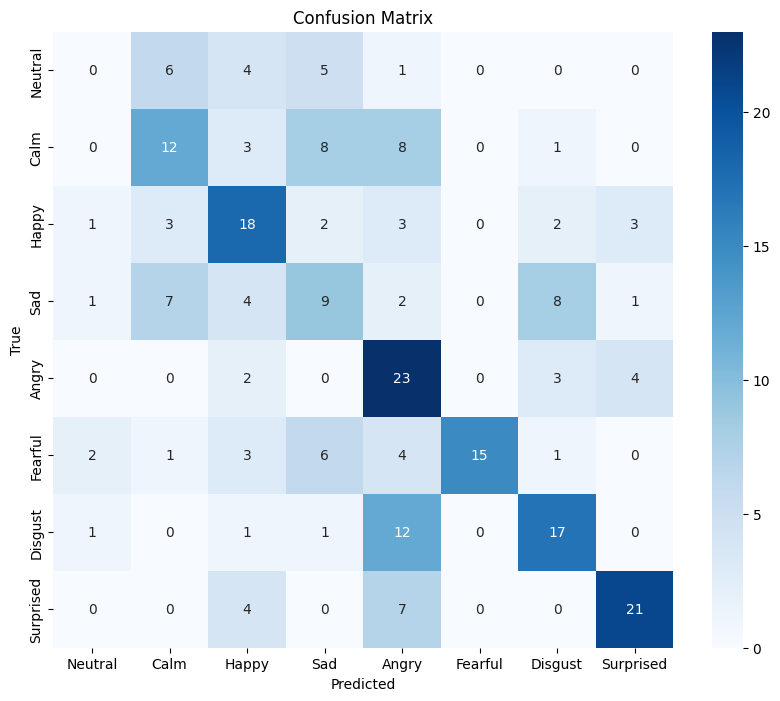

In [22]:
# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    preds,
    target_names=list(EMOTION_MAP.values())
))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(EMOTION_MAP.values()),
    yticklabels=list(EMOTION_MAP.values())
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [23]:
import joblib

joblib.dump(model, "ser_model.pkl")

['ser_model.pkl']